In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('./USA_Housing.csv')
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   str    
dtypes: float64(6), str(1)
memory usage: 273.6 KB


In [3]:
data.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [4]:
data.drop(
    columns=['Address'],
    inplace=True
)

In [5]:
data['Area Population'] = data['Area Population'].astype('int64')
data.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
0,79545.458574,5.682861,7.009188,4.09,23086,1.059034e+06
1,79248.642455,6.002900,6.730821,3.09,40173,1.505891e+06
2,61287.067179,5.865890,8.512727,5.13,36882,1.058988e+06
3,63345.240046,7.188236,5.586729,3.26,34310,1.260617e+06
4,59982.197226,5.040555,7.839388,4.23,26354,6.309435e+05


In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   int64  
 5   Price                         5000 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 234.5 KB


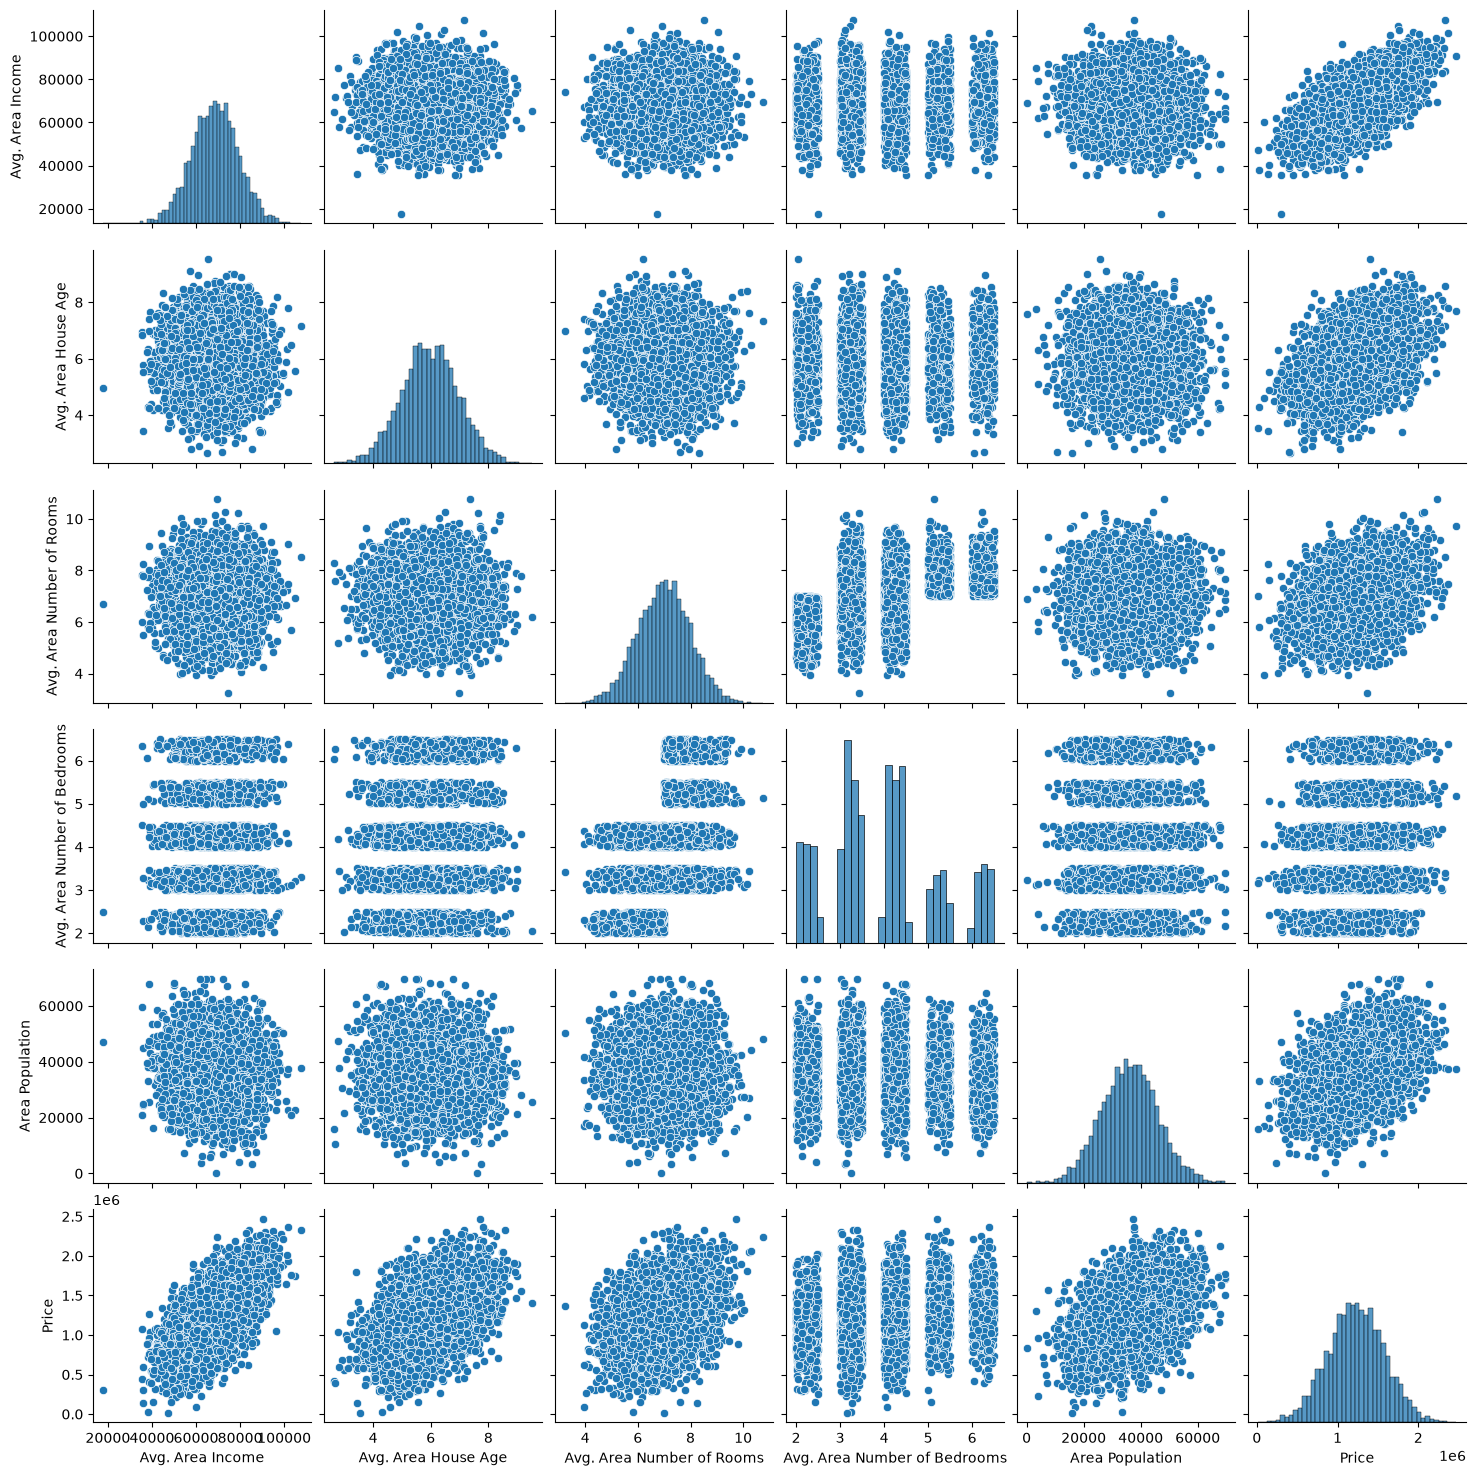

In [7]:
sns.pairplot(data)

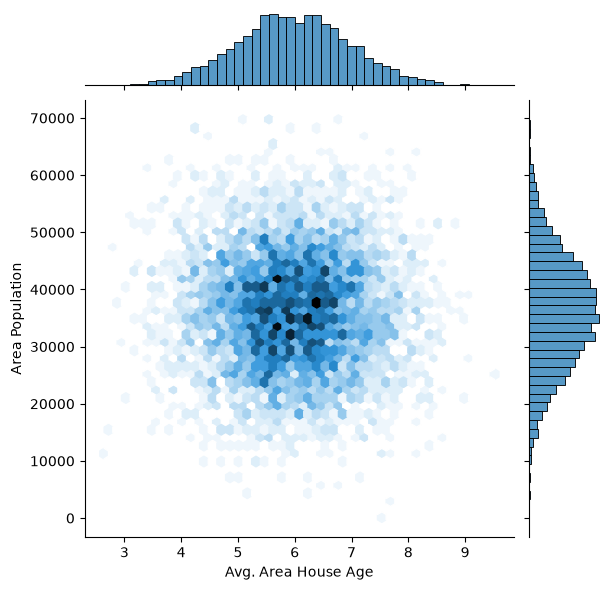

In [8]:
sns.jointplot(data=data, x='Avg. Area House Age', y='Area Population',kind='hex')

In [9]:
corr = data.corr()
corr

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
Avg. Area Income,1.000000,-0.002007,-0.011032,0.019788,-0.016234,0.639734
Avg. Area House Age,-0.002007,1.000000,-0.009428,0.006149,-0.018742,0.452543
Avg. Area Number of Rooms,-0.011032,-0.009428,1.000000,0.462695,0.002040,0.335664
Avg. Area Number of Bedrooms,0.019788,0.006149,0.462695,1.000000,-0.022167,0.171071
Area Population,-0.016234,-0.018742,0.002040,-0.022167,1.000000,0.408556
Price,0.639734,0.452543,0.335664,0.171071,0.408556,1.000000


<Axes: >

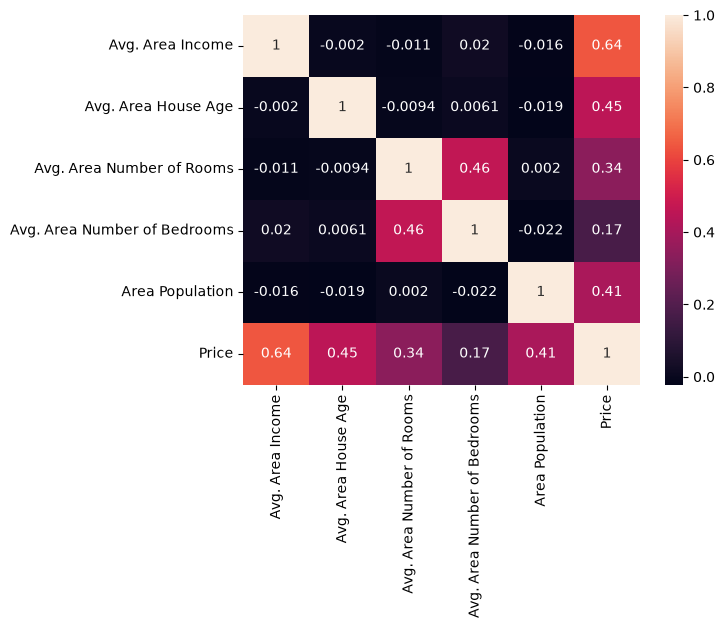

In [10]:
sns.heatmap(corr,annot=True)

In [11]:
from sklearn.model_selection import train_test_split
features = data.drop(columns = 'Price')

In [12]:
features

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population
0,79545.458574,5.682861,7.009188,4.09,23086
1,79248.642455,6.002900,6.730821,3.09,40173
2,61287.067179,5.865890,8.512727,5.13,36882
3,63345.240046,7.188236,5.586729,3.26,34310
4,59982.197226,5.040555,7.839388,4.23,26354
...,...,...,...,...,...
4995,60567.944140,7.830362,6.137356,3.46,22837
4996,78491.275435,6.999135,6.576763,4.02,25616
4997,63390.686886,7.250591,4.805081,2.13,33266
4998,68001.331235,5.534388,7.130144,5.44,42625


In [13]:
target = data['Price']
target

0       1.059034e+06
1       1.505891e+06
2       1.058988e+06
3       1.260617e+06
4       6.309435e+05
            ...     
4995    1.060194e+06
4996    1.482618e+06
4997    1.030730e+06
4998    1.198657e+06
4999    1.298950e+06
Name: Price, Length: 5000, dtype: float64

In [28]:
train_test_split(features, target)

[      Avg. Area Income  Avg. Area House Age  Avg. Area Number of Rooms  \
 2370      81272.395584             7.123967                   7.169950   
 1144      83586.901564             6.616144                   7.483347   
 1729      53173.345282             5.503955                   6.879954   
 363       75175.873113             8.561762                   5.197254   
 3742      73030.842968             7.989984                   6.411736   
 ...                ...                  ...                        ...   
 3803      65718.301974             4.907385                   4.147431   
 1495      77905.827189             5.041209                   7.881144   
 1052      58599.615600             5.666214                   7.067575   
 2456      67041.967661             6.021458                   5.346830   
 3935      65258.213677             8.254233                   7.858383   
 
       Avg. Area Number of Bedrooms  Area Population  
 2370                          3.33        

In [30]:
X_Train, X_test, Y_train, Y_test = train_test_split(features, target,random_state=100, train_size=.8)

In [35]:
X_Train


,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population
4833,61000.160428,6.691542,7.859604,3.47,60697
1218,71172.489061,5.780419,6.102668,4.16,23264
135,74411.059892,5.534628,7.210123,6.44,43537
3612,61685.756042,5.124393,5.604803,3.27,36059
3259,65207.736246,5.997596,8.022923,4.02,29668
...,...,...,...,...,...
4149,76717.097365,5.577625,7.197195,3.11,22276
1890,54447.686052,6.148759,6.077189,2.40,50200
350,81328.807304,6.483153,6.908830,3.01,31231
79,64419.252638,6.954422,8.516160,6.16,39318


In [ ]:
[1,1,1,1,2,2,2,2,2,2,3,3,3,3]
